# 📘 Day 3 — Data Visualisation
**SDNB Vaishnav College for Women, Chromepet**

**Date:** Wednesday, 29 April 2026 | **Duration:** 9:30 AM – 1:00 PM (3 hours)

---

### 🎯 By the end of today you will:
- ✅ Build **bar charts** (single, grouped, styled, annotated)
- ✅ Draw **pie & donut charts** for market share
- ✅ Draw **histograms** for customer demographics
- ✅ Plot **scatter plots** with trend lines and quadrants
- ✅ Combine all four into a single **2×2 dashboard**

In [1]:
# ── Install & Setup (run this first on Google Colab) ──
import sys, os

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    print("✅ All libraries ready!")
except ImportError as e:
    print(f"Installing missing library: {e}")
    os.system("pip install pandas matplotlib numpy seaborn -q")
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np

# Where the CSV data files live.
# - On Colab after uploading the workshop folder: "/content/sdnb_python_workshop/data/"
# - When running locally from notebooks/ folder:   "../data/"
DATA_PATH = "../data/" if os.path.exists("../data") else "data/"
print(f"📁 Using data path: {DATA_PATH}")

✅ All libraries ready!
📁 Using data path: ../data/


## 🔁 Quick Recap of Day 2 *(5 min)*

Yesterday we wrote **functions** — reusable blocks of code. Today we'll *use* functions and lists to drive *charts*. Charts are how the numbers become a story.

> **Analogy:** A chart is like a **financial dashboard**. Instead of reading 100 rows of figures, one bar chart tells you instantly which month performed best. Finance directors look at charts before they look at raw data. You're learning to build those charts.

## 📊 Section 1 — Introduction to Matplotlib *(15 min)*

```python
import matplotlib.pyplot as plt   # The main charting library (like Excel charts)
import numpy as np                # For number arrays (like a smart list)
import seaborn as sns             # Pretty defaults — used later
```

**Anatomy of a Matplotlib chart:**

```
Figure → Canvas (the whole image)
  └── Axes → The actual plot area
        ├── Title
        ├── X-axis label & ticks
        ├── Y-axis label & ticks
        └── Data (bars / slices / dots / line)
```

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Professional, clean look
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")    # fallback
plt.rcParams["font.family"]   = "DejaVu Sans"
plt.rcParams["figure.dpi"]    = 100

# Make a charts/ folder so we can save outputs
os.makedirs("../charts", exist_ok=True) if os.path.exists("../charts") or os.path.exists("..") else os.makedirs("charts", exist_ok=True)
CHART_DIR = "../charts/" if os.path.isdir("../charts") else "charts/"
print("📁 Charts will be saved into:", CHART_DIR)

📁 Charts will be saved into: ../charts/


## 📊 Chart 1 — Monthly Expenses Bar Chart *(40 min)*

**Scenario:** *SDNB College's Administration Office wants to visualise where the budget is going each month.*

We'll build the chart **in 4 versions**, adding one new idea each time.

In [3]:
categories   = ["Rent", "Salaries", "Utilities", "Marketing", "Stationery", "Events", "IT & Tech"]
jan_expenses = [85000, 320000, 12000, 45000, 8000, 25000, 15000]
apr_expenses = [85000, 335000, 14000, 62000, 6000, 80000, 22000]

### Version 1 — Basic bar chart (just data)

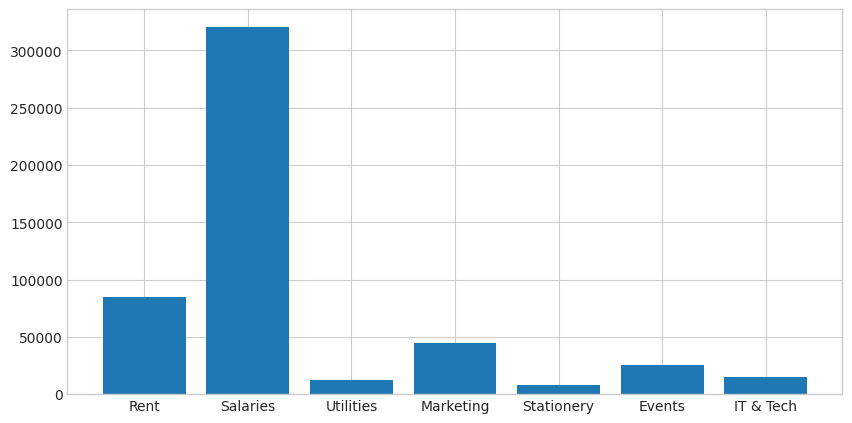

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(categories, jan_expenses)
plt.show()

**🔍 What did we add?** Nothing fancy — just bars. No title, no labels, no values shown. Functional but unreadable.

### Version 2 — Title, axis labels, value labels on bars

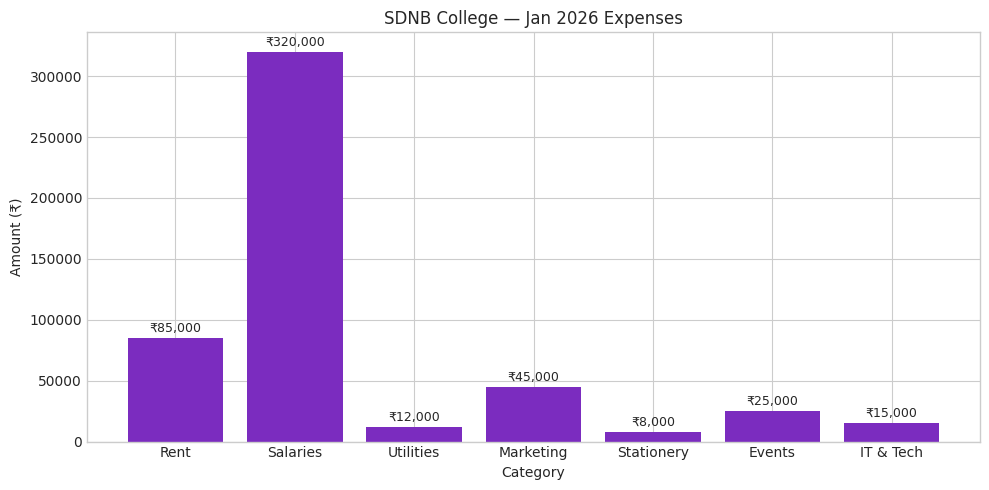

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(categories, jan_expenses, color="#7B2CBF")
ax.set_title("SDNB College — Jan 2026 Expenses")
ax.set_xlabel("Category")
ax.set_ylabel("Amount (₹)")

# Drop labels on top of each bar
for b, v in zip(bars, jan_expenses):
    ax.text(b.get_x() + b.get_width() / 2, v + 5000, f"₹{v:,}",
            ha="center", fontsize=9)

plt.tight_layout()
plt.show()

**🔍 What did we added?** A title, axis labels, and tiny value labels above each bar. Now anyone glancing at the chart understands what's plotted.

### Version 3 — Grouped bar chart with legend (Jan vs Apr)

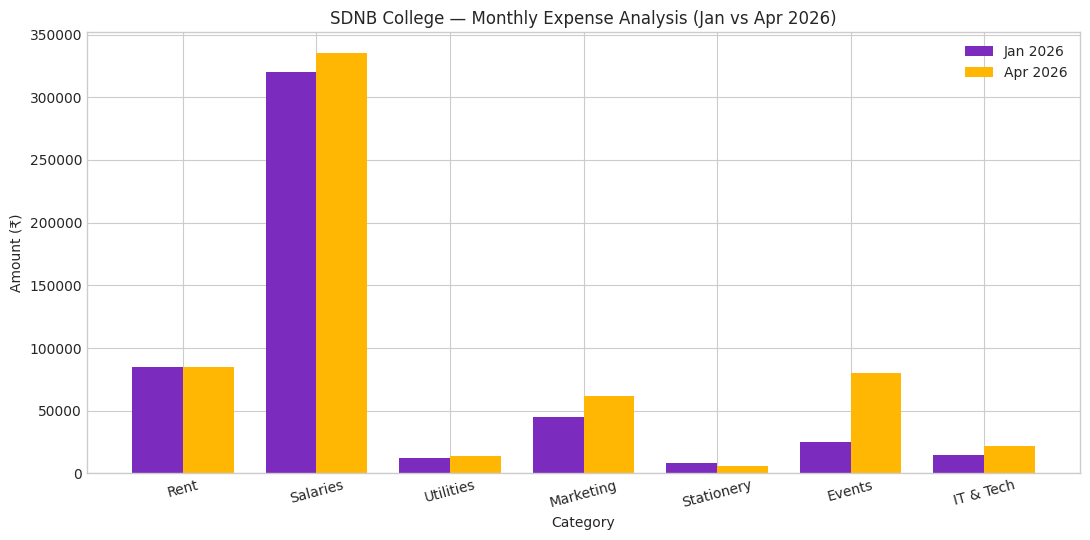

In [6]:
import numpy as np

x      = np.arange(len(categories))
width  = 0.38

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(x - width/2, jan_expenses, width, label="Jan 2026", color="#7B2CBF")
ax.bar(x + width/2, apr_expenses, width, label="Apr 2026", color="#FFB703")

ax.set_title("SDNB College — Monthly Expense Analysis (Jan vs Apr 2026)")
ax.set_xlabel("Category")
ax.set_ylabel("Amount (₹)")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**🔍 What did we add?** Two bars side-by-side per category, plus a legend showing which colour means which month. Comparison becomes obvious.

### Version 4 — Publication quality with budget line and annotations

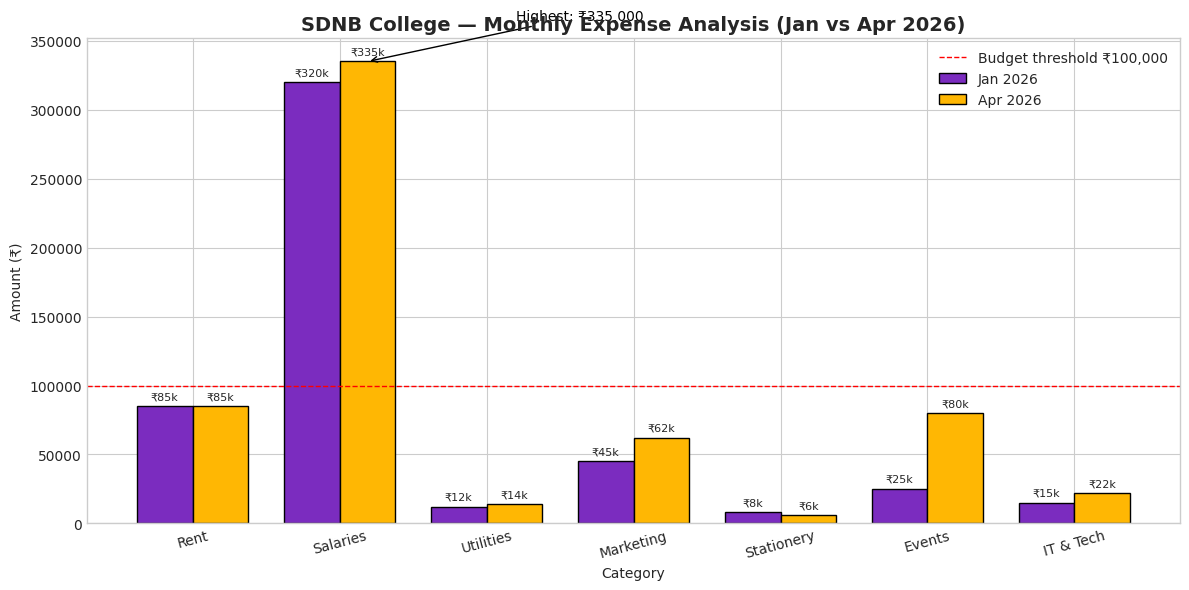

✅ Saved ../charts/expense_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, jan_expenses, width, label="Jan 2026",
               color="#7B2CBF", edgecolor="black")
bars2 = ax.bar(x + width/2, apr_expenses, width, label="Apr 2026",
               color="#FFB703", edgecolor="black")

# Budget threshold line
budget_line = 100000
ax.axhline(budget_line, color="red", linestyle="--", linewidth=1,
           label=f"Budget threshold ₹{budget_line:,}")

# Highest expense annotation
max_apr = max(apr_expenses)
max_idx = apr_expenses.index(max_apr)
ax.annotate(f"Highest: ₹{max_apr:,}",
            xy=(max_idx + width/2, max_apr),
            xytext=(max_idx + 1.2, max_apr + 30000),
            arrowprops=dict(arrowstyle="->", color="black"),
            fontsize=10, color="black")

# Value labels
for bars, vals in [(bars1, jan_expenses), (bars2, apr_expenses)]:
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 5000, f"₹{v//1000}k",
                ha="center", fontsize=8)

ax.set_title("SDNB College — Monthly Expense Analysis (Jan vs Apr 2026)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Amount (₹)")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(CHART_DIR + "expense_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved", CHART_DIR + "expense_comparison.png")

**🔍 What did we add?** A red dashed budget line, a callout arrow on the highest expense, value labels in `₹XXk` form, larger title. This is the publication-quality version a CFO would happily look at.

### Same chart from `monthly_expenses.csv`

  Month   Rent  Salary  Utilities  Marketing   Misc
0   Jan  85000  320824      11603      49400  22144
1   Feb  85000  322102      12536      62257  19834
2   Mar  85000  321924      14109      56070  20315
3   Apr  85000  324765      11122      65567  14072
4   May  85000  327064      15424      34687  17340


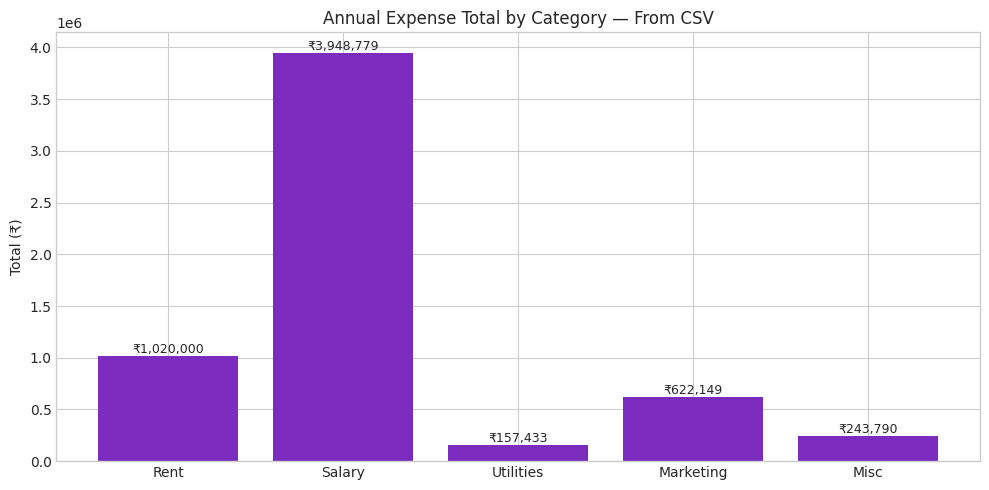

In [8]:
import pandas as pd

df_exp = pd.read_csv(DATA_PATH + "monthly_expenses.csv")
print(df_exp.head())

# Total per category column (excluding Month) for the year
totals = df_exp.drop(columns="Month").sum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(totals.index, totals.values, color="#7B2CBF")
ax.set_title("Annual Expense Total by Category — From CSV")
ax.set_ylabel("Total (₹)")
for i, v in enumerate(totals.values):
    ax.text(i, v, f"₹{int(v):,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 🥧 Chart 2 — Brand Market Share Pie Chart *(30 min)*

**Scenario:** *A Chennai textile distributor wants to understand which brands are dominating their sales.*

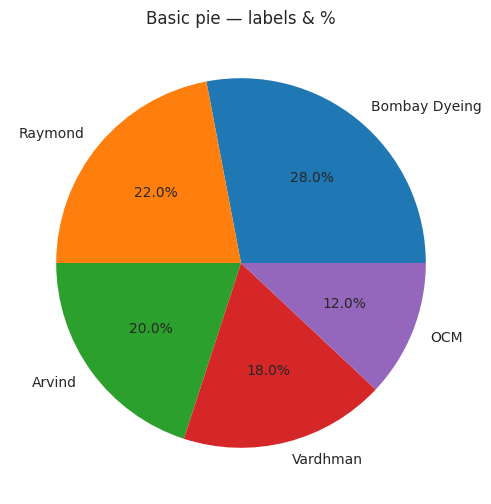

In [9]:
brands = ["Bombay Dyeing", "Raymond", "Arvind", "Vardhman", "OCM"]
market_share = [28, 22, 20, 18, 12]
sales_inr    = [s * 50000 for s in market_share]   # mock absolute values

# Version 1 — basic pie
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(market_share, labels=brands, autopct="%1.1f%%")
ax.set_title("Basic pie — labels & %")
plt.show()

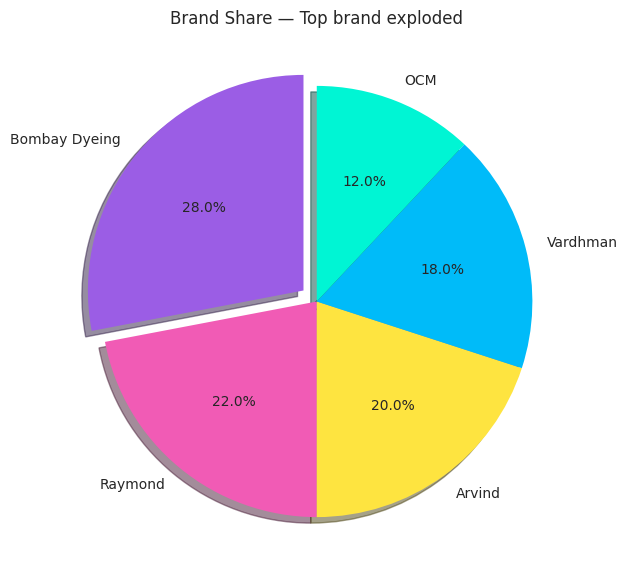

In [10]:
# Version 2 — explode the top brand, percentage labels
explode = [0.08 if s == max(market_share) else 0 for s in market_share]
colors  = ["#9B5DE5", "#F15BB5", "#FEE440", "#00BBF9", "#00F5D4"]

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(market_share, labels=brands, autopct="%1.1f%%",
       explode=explode, colors=colors,
       startangle=90, shadow=True)
ax.set_title("Brand Share — Top brand exploded")
plt.show()

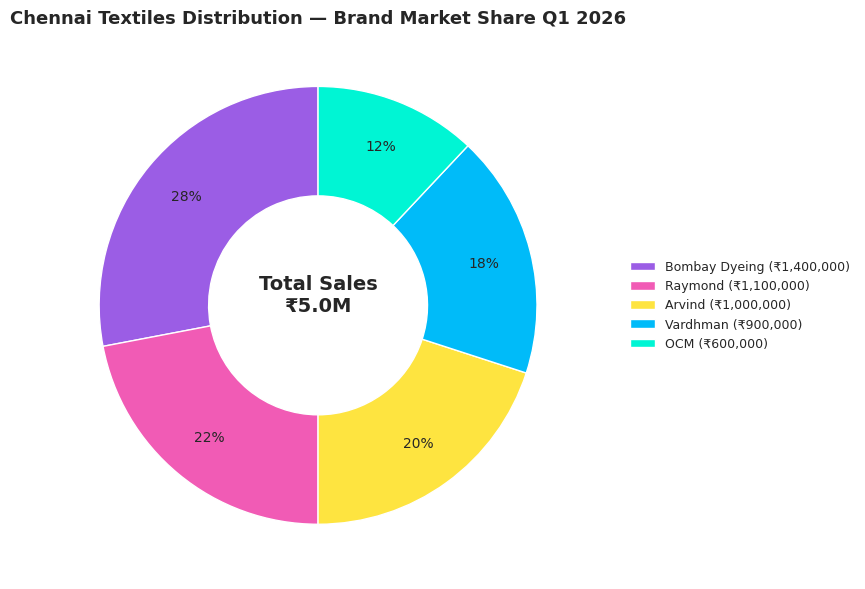

In [11]:
# Version 3 — Donut chart with total in centre
fig, ax = plt.subplots(figsize=(8, 7))
wedges, texts, autotexts = ax.pie(
    market_share, labels=None,
    autopct=lambda p: f"{p:.0f}%",
    colors=colors, startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white"),
    pctdistance=0.78,
)
total = sum(sales_inr)
ax.text(0, 0.05, f"Total Sales\n₹{total/1e6:.1f}M", ha="center", va="center",
        fontsize=14, fontweight="bold")
ax.legend(wedges, [f"{b} (₹{s:,})" for b, s in zip(brands, sales_inr)],
          loc="center left", bbox_to_anchor=(1.05, 0.5), fontsize=9)
ax.set_title("Chennai Textiles Distribution — Brand Market Share Q1 2026",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(CHART_DIR + "brand_share.png", bbox_inches="tight", dpi=150)
plt.show()

**📊 Business Insight:** *Bombay Dyeing dominates with 28% share. The bottom 2 brands (Vardhman + OCM) together hold 30% — only marginally more than the leader alone. Management should review distribution focus and either grow Vardhman/OCM or rationalise the lineup.*

## 📈 Chart 3 — Customer Age Distribution Histogram *(30 min)*

**Scenario:** *The Marketing Manager of a Chennai retail chain wants to understand the age profile of their customers to target campaigns better.*

In [12]:
import os

try:
    df_cust = pd.read_csv(DATA_PATH + "customer_ages.csv")
    print(f"✅ Loaded {len(df_cust)} customers from CSV")
except FileNotFoundError:
    # Fallback random sample
    rng = np.random.default_rng(0)
    df_cust = pd.DataFrame({
        "Age": rng.integers(18, 70, size=100),
        "Segment": rng.choice(["Premium", "Regular"], size=100),
    })
    print("⚠️  CSV not found — using random fallback")

ages = pd.to_numeric(df_cust["Age"], errors="coerce").dropna().astype(int)
print("Stats →", "n=", len(ages), "mean=", round(ages.mean(), 1),
      "min=", ages.min(), "max=", ages.max())

✅ Loaded 100 customers from CSV
Stats → n= 98 mean= 34.4 min= 19 max= 68


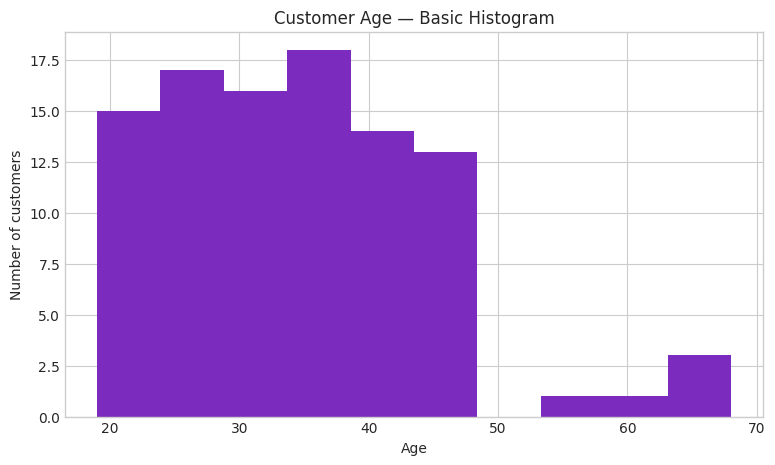

In [13]:
# Version 1 — Basic histogram
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(ages, bins=10, color="#7B2CBF")
ax.set_title("Customer Age — Basic Histogram")
ax.set_xlabel("Age")
ax.set_ylabel("Number of customers")
plt.show()

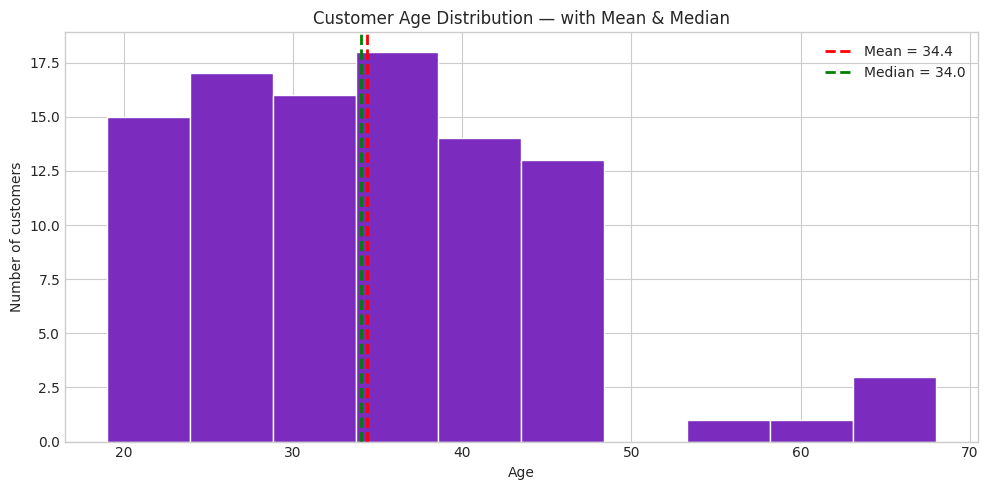

In [14]:
# Version 2 — styled with mean & median lines
mean_age   = ages.mean()
median_age = ages.median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ages, bins=10, color="#7B2CBF", edgecolor="white")
ax.axvline(mean_age,   color="red",   linestyle="--", linewidth=2, label=f"Mean = {mean_age:.1f}")
ax.axvline(median_age, color="green", linestyle="--", linewidth=2, label=f"Median = {median_age:.1f}")
ax.set_title("Customer Age Distribution — with Mean & Median")
ax.set_xlabel("Age")
ax.set_ylabel("Number of customers")
ax.legend()
plt.tight_layout()
plt.show()

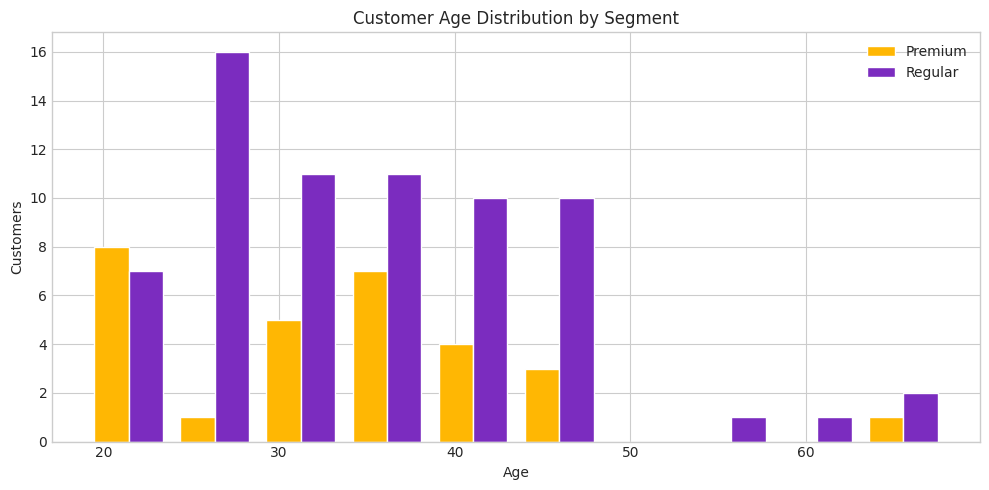

In [15]:
# Version 3 — Side-by-side by Segment (Premium vs Regular)
df_clean = df_cust.copy()
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")
df_clean = df_clean.dropna(subset=["Age"])

premium = df_clean.loc[df_clean["Segment"] == "Premium", "Age"]
regular = df_clean.loc[df_clean["Segment"] == "Regular", "Age"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([premium, regular], bins=10,
        label=["Premium", "Regular"],
        color=["#FFB703", "#7B2CBF"],
        edgecolor="white")
ax.set_title("Customer Age Distribution by Segment")
ax.set_xlabel("Age")
ax.set_ylabel("Customers")
ax.legend()
plt.tight_layout()
plt.savefig(CHART_DIR + "age_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

### 📊 Statistics & marketing recommendation

In [16]:
mode_band = pd.cut(ages, bins=[15,25,35,45,55,70]).value_counts().idxmax()
youngest, oldest = ages.min(), ages.max()
in_band = pd.cut(ages, bins=[15,25,35,45,55,70]).value_counts(normalize=True).max() * 100

print(f"Mean age          : {mean_age:.1f}")
print(f"Median age        : {median_age:.1f}")
print(f"Modal age band    : {mode_band}")
print(f"Youngest customer : {youngest}")
print(f"Oldest customer   : {oldest}")
print(f"% in modal band   : {in_band:.1f}%")
print()
print(f"💡 Most customers are in {mode_band} ({in_band:.0f}% of total). "
      f"Run campaigns aimed at this age group; allocate a smaller secondary budget for under-25 acquisition.")

Mean age          : 34.4
Median age        : 34.0
Modal age band    : (35, 45]
Youngest customer : 19
Oldest customer   : 68
% in modal band   : 36.7%

💡 Most customers are in (35, 45] (37% of total). Run campaigns aimed at this age group; allocate a smaller secondary budget for under-25 acquisition.


## 🎯 Chart 4 — Ad Spend vs Sales Scatter Plot *(35 min)*

**Scenario:** *The CFO of a mid-sized FMCG company asks: is our advertising spend actually generating sales? Show me the relationship visually.*

In [17]:
try:
    df_ads = pd.read_csv(DATA_PATH + "ad_spend.csv")
    print(f"✅ Loaded {len(df_ads)} months of ad spend data")
except FileNotFoundError:
    rng = np.random.default_rng(1)
    n   = 24
    spend = rng.uniform(40_000, 220_000, n)
    sales = 8 * spend + rng.normal(0, 80_000, n)
    df_ads = pd.DataFrame({"Month": [f"M{i}" for i in range(n)],
                           "AdSpend": spend, "SalesRevenue": sales,
                           "Channel": rng.choice(["Digital","Print","Outdoor","Social"], n)})

df_ads.head()

✅ Loaded 24 months of ad spend data


,Month,AdSpend,SalesRevenue,Channel
0,2024-01,145585.25,1189389.27,Digital
1,2024-02,185011.10,1481999.29,Print
2,2024-03,146699.67,1226794.70,Outdoor
3,2024-04,54640.69,452408.91,Social
4,2024-05,151598.18,1175145.21,Digital


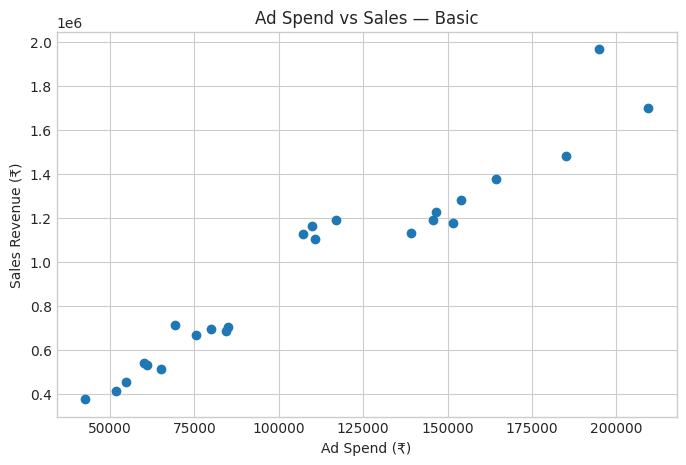

In [18]:
# Version 1 — basic scatter
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_ads["AdSpend"], df_ads["SalesRevenue"])
ax.set_title("Ad Spend vs Sales — Basic")
ax.set_xlabel("Ad Spend (₹)")
ax.set_ylabel("Sales Revenue (₹)")
plt.show()

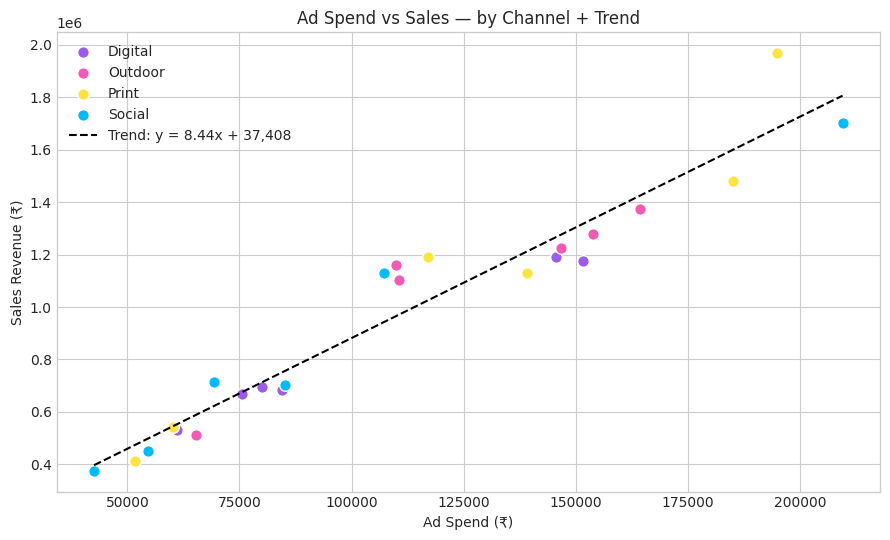

In [19]:
# Version 2 — coloured by channel + trend line
channels = sorted(df_ads["Channel"].unique())
palette  = dict(zip(channels, ["#9B5DE5", "#F15BB5", "#FEE440", "#00BBF9"]))

fig, ax = plt.subplots(figsize=(9, 5.5))
for ch in channels:
    sub = df_ads[df_ads["Channel"] == ch]
    ax.scatter(sub["AdSpend"], sub["SalesRevenue"],
               s=70, color=palette[ch], label=ch, edgecolor="white")

# numpy polyfit trend line (degree 1 = linear)
m, b = np.polyfit(df_ads["AdSpend"], df_ads["SalesRevenue"], 1)
xline = np.linspace(df_ads["AdSpend"].min(), df_ads["AdSpend"].max(), 50)
ax.plot(xline, m * xline + b, "k--", linewidth=1.5,
        label=f"Trend: y = {m:.2f}x + {b:,.0f}")

ax.set_title("Ad Spend vs Sales — by Channel + Trend")
ax.set_xlabel("Ad Spend (₹)")
ax.set_ylabel("Sales Revenue (₹)")
ax.legend()
plt.tight_layout()
plt.show()

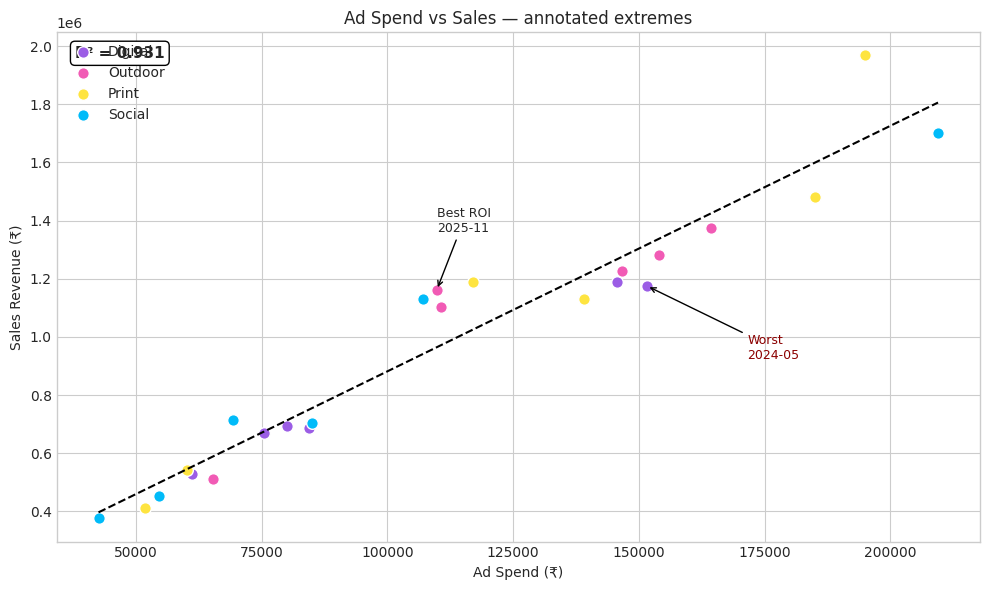

In [20]:
# Version 3 — annotate best & worst months + R²
df_ads = df_ads.copy()
df_ads["ROI"] = df_ads["SalesRevenue"] / df_ads["AdSpend"]
best  = df_ads.loc[df_ads["ROI"].idxmax()]
worst = df_ads.loc[df_ads["ROI"].idxmin()]

# R² of linear fit
ss_res = ((df_ads["SalesRevenue"] - (m * df_ads["AdSpend"] + b)) ** 2).sum()
ss_tot = ((df_ads["SalesRevenue"] - df_ads["SalesRevenue"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

fig, ax = plt.subplots(figsize=(10, 6))
for ch in channels:
    sub = df_ads[df_ads["Channel"] == ch]
    ax.scatter(sub["AdSpend"], sub["SalesRevenue"],
               s=70, color=palette[ch], label=ch, edgecolor="white")
ax.plot(xline, m * xline + b, "k--", linewidth=1.5)

ax.annotate(f"Best ROI\n{best['Month']}",
            xy=(best["AdSpend"], best["SalesRevenue"]),
            xytext=(best["AdSpend"], best["SalesRevenue"] + 200000),
            arrowprops=dict(arrowstyle="->"), fontsize=9)
ax.annotate(f"Worst\n{worst['Month']}",
            xy=(worst["AdSpend"], worst["SalesRevenue"]),
            xytext=(worst["AdSpend"] + 20000, worst["SalesRevenue"] - 250000),
            arrowprops=dict(arrowstyle="->"), fontsize=9, color="darkred")

ax.text(0.02, 0.95, f"R² = {r2:.3f}", transform=ax.transAxes,
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white"))
ax.set_title("Ad Spend vs Sales — annotated extremes")
ax.set_xlabel("Ad Spend (₹)")
ax.set_ylabel("Sales Revenue (₹)")
ax.legend()
plt.tight_layout()
plt.show()

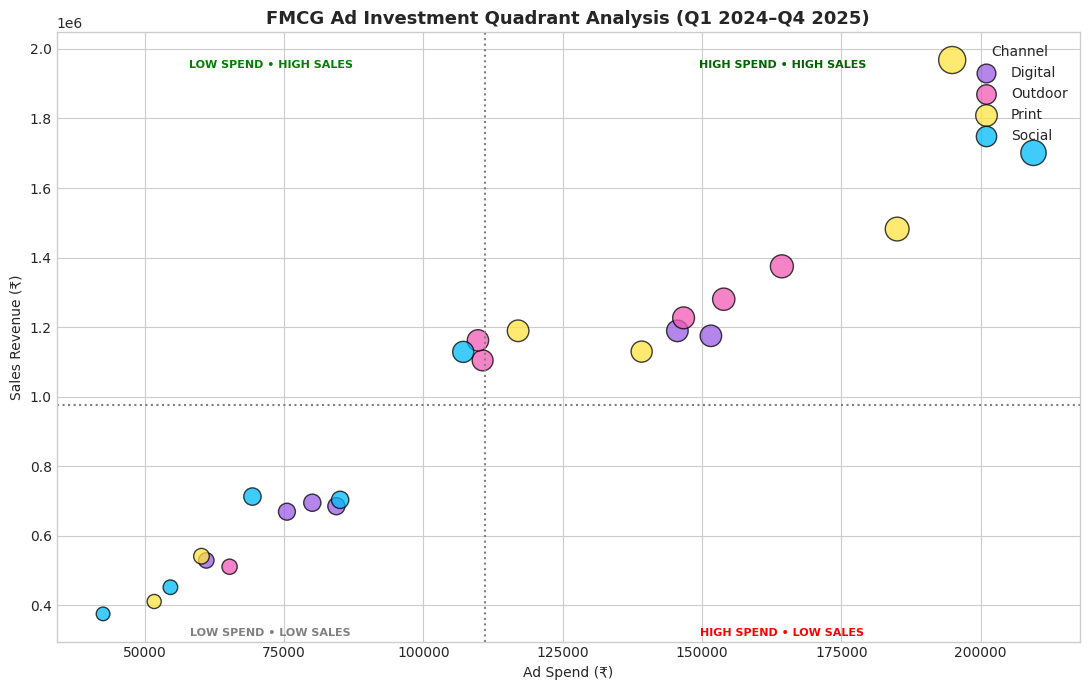


💡 Channel ROI ranking (Sales per ₹ of ad spend):
Channel
Social     9.05
Outdoor    8.91
Print      8.89
Digital    8.38

Overall correlation (R) = 0.965
Linear fit slope        = ₹8.44 of sales per ₹1 of ad spend


In [21]:
# Version 4 — quadrant analysis
mean_spend = df_ads["AdSpend"].mean()
mean_sales = df_ads["SalesRevenue"].mean()

fig, ax = plt.subplots(figsize=(11, 7))
sizes = (df_ads["SalesRevenue"] / df_ads["SalesRevenue"].max()) * 350 + 30
for ch in channels:
    sub  = df_ads[df_ads["Channel"] == ch]
    s_sz = sizes[df_ads["Channel"] == ch]
    ax.scatter(sub["AdSpend"], sub["SalesRevenue"],
               s=s_sz, color=palette[ch], label=ch,
               edgecolor="black", alpha=0.75)

ax.axvline(mean_spend, color="grey", linestyle=":")
ax.axhline(mean_sales, color="grey", linestyle=":")

# Quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[0] + (mean_spend - xlim[0])/2, ylim[1]*0.95, "LOW SPEND • HIGH SALES",
        ha="center", fontsize=8, color="green", fontweight="bold")
ax.text((xlim[1] + mean_spend)/2,           ylim[1]*0.95, "HIGH SPEND • HIGH SALES",
        ha="center", fontsize=8, color="darkgreen", fontweight="bold")
ax.text(xlim[0] + (mean_spend - xlim[0])/2, ylim[0]*1.05, "LOW SPEND • LOW SALES",
        ha="center", fontsize=8, color="grey", fontweight="bold")
ax.text((xlim[1] + mean_spend)/2,           ylim[0]*1.05, "HIGH SPEND • LOW SALES",
        ha="center", fontsize=8, color="red", fontweight="bold")

ax.set_title("FMCG Ad Investment Quadrant Analysis (Q1 2024–Q4 2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Ad Spend (₹)")
ax.set_ylabel("Sales Revenue (₹)")
ax.legend(title="Channel")
plt.tight_layout()
plt.savefig(CHART_DIR + "ad_quadrant.png", bbox_inches="tight", dpi=150)
plt.show()

# Channel-wise ROI summary
roi_by_channel = df_ads.groupby("Channel")["ROI"].mean().round(2).sort_values(ascending=False)
print("\n💡 Channel ROI ranking (Sales per ₹ of ad spend):")
print(roi_by_channel.to_string())
print(f"\nOverall correlation (R) = {np.sqrt(r2):.3f}")
print(f"Linear fit slope        = ₹{m:.2f} of sales per ₹1 of ad spend")

## 🎛️ Bonus — All Four Charts in One Dashboard

A preview of Day 4's KPI dashboard work. We arrange four charts in a 2×2 grid using `plt.subplots(2, 2)`.

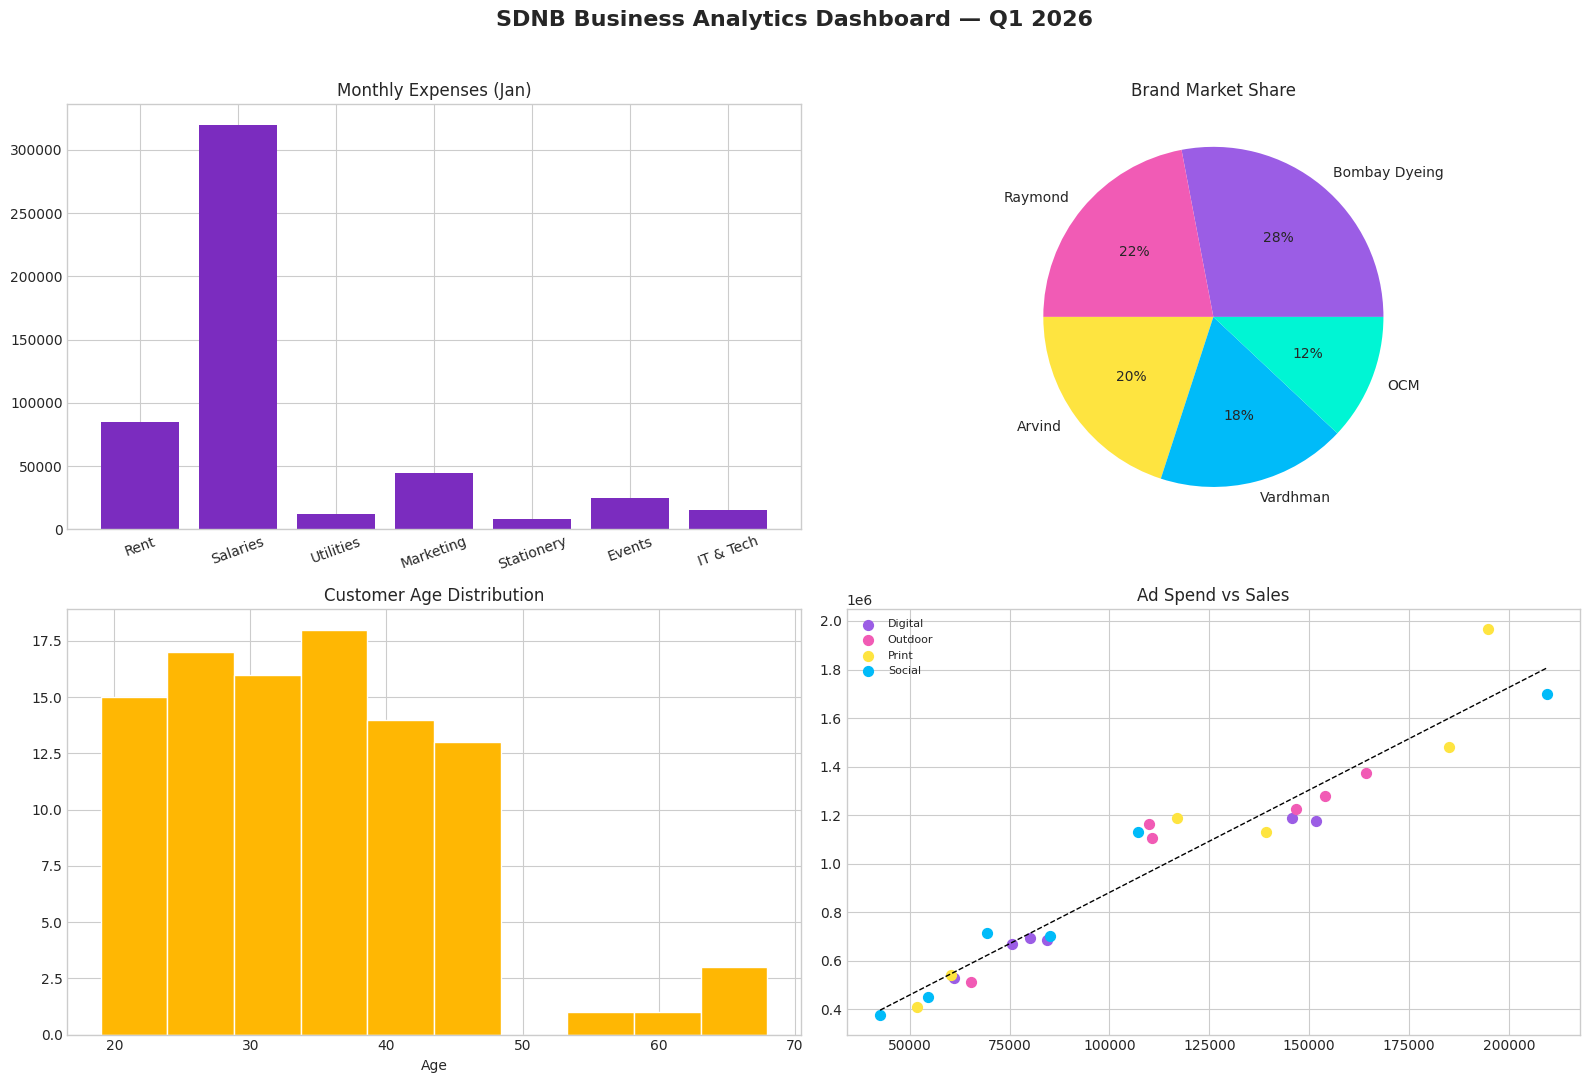

✅ Saved ../charts/business_dashboard.png


In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("SDNB Business Analytics Dashboard — Q1 2026",
             fontsize=16, fontweight="bold")

# Top-left: bar chart
axes[0, 0].bar(categories, jan_expenses, color="#7B2CBF")
axes[0, 0].set_title("Monthly Expenses (Jan)")
axes[0, 0].tick_params(axis="x", rotation=20)

# Top-right: pie chart
axes[0, 1].pie(market_share, labels=brands, autopct="%1.0f%%", colors=colors)
axes[0, 1].set_title("Brand Market Share")

# Bottom-left: histogram
axes[1, 0].hist(ages, bins=10, color="#FFB703", edgecolor="white")
axes[1, 0].set_title("Customer Age Distribution")
axes[1, 0].set_xlabel("Age")

# Bottom-right: scatter
for ch in channels:
    sub = df_ads[df_ads["Channel"] == ch]
    axes[1, 1].scatter(sub["AdSpend"], sub["SalesRevenue"],
                       s=50, color=palette[ch], label=ch)
axes[1, 1].plot(xline, m * xline + b, "k--", linewidth=1)
axes[1, 1].set_title("Ad Spend vs Sales")
axes[1, 1].legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(CHART_DIR + "business_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Saved", CHART_DIR + "business_dashboard.png")

## 📚 Key Concepts Today

| Concept | Used in |
|---------|---------|
| `plt.subplots()` | Every chart |
| `ax.bar()` | Expense comparison |
| `ax.pie()` with `wedgeprops`, `explode` | Market share, donut |
| `ax.hist()` | Age distribution |
| `ax.scatter()` with sizes/colors | Ad spend |
| `np.polyfit` for trend lines | Scatter |
| Annotations & axhline | Highlighting extremes |
| `plt.savefig` | Saving every chart to `charts/` |

---

➡️ **Next: Day 4 Morning — Pandas.** We move from drawing single charts to *analysing* whole CSV files. Pandas is Excel inside Python.